In [1]:
import pandas as pd

df_clean = pd.read_csv('../data/online_retail_clean.csv', parse_dates=['InvoiceDate'])
df_clean.head()

C:\Users\juanr\AppData\Local\Temp\ipykernel_7580\2598936289.py:3: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv('../data/online_retail_clean.csv', parse_dates=['InvoiceDate'])


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [2]:
# Solo clientes identificados (descartamos los que no tienen Customer ID)
df_rfm = df_clean[df_clean['Customer ID'].notna()].copy()

# Fecha de referencia: un día después de la última compra registrada en todo el dataset
snapshot_date = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_rfm.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recencia (días desde la última compra)
    'Invoice': 'nunique',                                      # Frecuencia (número de pedidos distintos)
    'Revenue': 'sum'                                            # Monetario (total gastado)
}).rename(columns={'InvoiceDate': 'Recency', 'Invoice': 'Frequency', 'Revenue': 'Monetary'})

print(rfm.describe())

           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289724    2955.904095
std     209.338707    13.009830   14440.852688
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     342.280000
50%      96.000000     3.000000     867.740000
75%     380.000000     7.000000    2248.305000
max     739.000000   398.000000  580987.040000


In [3]:
# Puntuar en cuartiles: 4 = mejor, 1 = peor
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)  # menos días = mejor
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segmentar(score):
    if score >= 10:
        return 'Campeones'
    elif score >= 7:
        return 'Leales'
    elif score >= 4:
        return 'En riesgo'
    else:
        return 'Perdidos'

rfm['Segmento'] = rfm['RFM_Score'].apply(segmentar)
print(rfm['Segmento'].value_counts())
print(rfm.groupby('Segmento')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

Segmento
En riesgo    1788
Leales       1779
Campeones    1740
Perdidos      571
Name: count, dtype: int64
           Recency  Frequency  Monetary
Segmento                               
Campeones     37.2       15.2    8056.4
En riesgo    308.8        1.6     456.6
Leales       142.8        3.9    1371.9
Perdidos     547.2        1.0     174.5


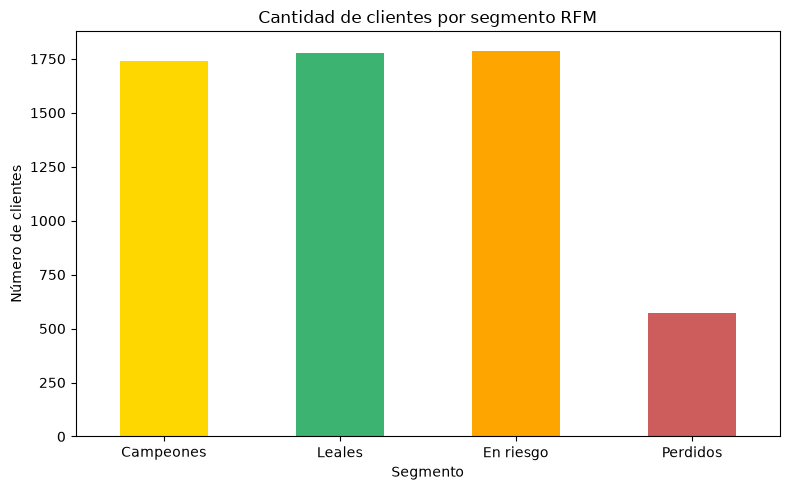

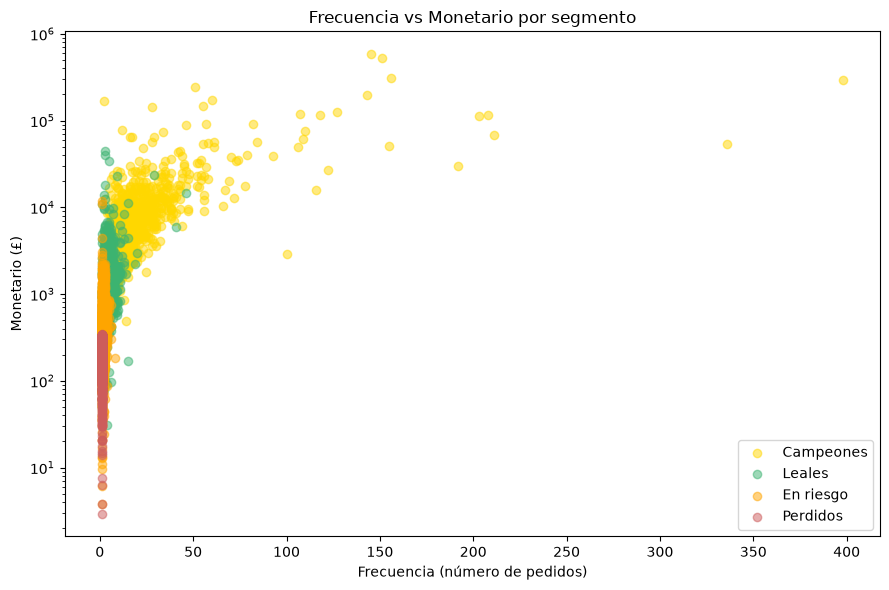

In [4]:
import matplotlib.pyplot as plt

# Tamaño de cada segmento
plt.figure(figsize=(8,5))
orden = ['Campeones','Leales','En riesgo','Perdidos']
colores = ['gold','mediumseagreen','orange','indianred']
rfm['Segmento'].value_counts().reindex(orden).plot(kind='bar', color=colores)
plt.title('Cantidad de clientes por segmento RFM')
plt.ylabel('Número de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Frecuencia vs Monetario, coloreado por segmento
plt.figure(figsize=(9,6))
mapa_color = dict(zip(orden, colores))
for segmento in orden:
    subset = rfm[rfm['Segmento'] == segmento]
    plt.scatter(subset['Frequency'], subset['Monetary'], label=segmento, alpha=0.5, color=mapa_color[segmento])
plt.xlabel('Frecuencia (número de pedidos)')
plt.ylabel('Monetario (£)')
plt.yscale('log')  # hay un cliente outlier con £580,987 que aplastaría la escala normal
plt.legend()
plt.title('Frecuencia vs Monetario por segmento')
plt.tight_layout()
plt.show()

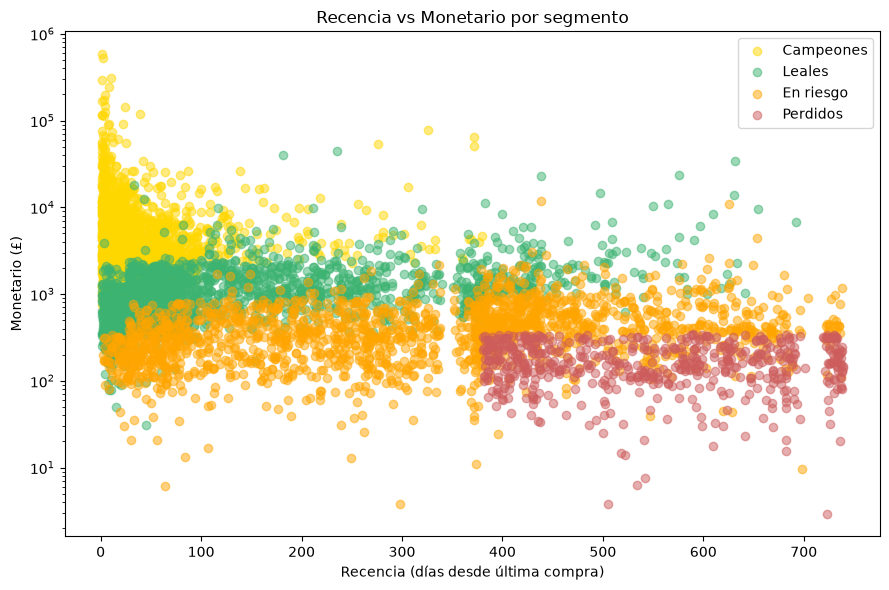

In [5]:
plt.figure(figsize=(9,6))
for segmento in orden:
    subset = rfm[rfm['Segmento'] == segmento]
    plt.scatter(subset['Recency'], subset['Monetary'], label=segmento, alpha=0.5, color=mapa_color[segmento])
plt.xlabel('Recencia (días desde última compra)')
plt.ylabel('Monetario (£)')
plt.yscale('log')
plt.legend()
plt.title('Recencia vs Monetario por segmento')
plt.tight_layout()
plt.show()